# Q1(b) — RANSAC Line Fitting for Three Lines

## Objective
Fit **three lines** to all the points in `lines.csv` using RANSAC.

The dataset has three groups of points mixed together.
We need to find one line at a time, remove its points, then find the next.

## Method
1. Flatten all x and y columns into one combined point set
2. Run RANSAC → find Line 1 → remove its inliers
3. Run RANSAC on what's left → find Line 2 → remove its inliers
4. Run RANSAC on what's left → find Line 3

## How RANSAC works (from lecture)
- Randomly pick 2 points and fit a line through them
- Check how many other points fall within a distance threshold (inliers)
- Repeat many times and keep the line with the most inliers
- Refit the line using all inliers for a better final estimate

This makes RANSAC robust to outliers — it ignores points that don't 
belong to the current line.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — Load and flatten all points
Using the exact code structure given in the assignment.
x1, x2, x3 columns flattened into one X array.
y1, y2, y3 columns flattened into one Y array.

In [6]:
# load the dataset
D = np.genfromtxt('../images/lines.csv', delimiter=',', skip_header=1)

# columns 0,1,2 are x values and columns 3,4,5 are y values
X_cols = D[:, :3]
Y_cols = D[:, 3:]

# flatten all columns into one big array - mixes all 3 line clusters together
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print(f"Total points (all 3 lines combined): {len(X_all)}")
print(f"X range: [{X_all.min():.2f}, {X_all.max():.2f}]")
print(f"Y range: [{Y_all.min():.2f}, {Y_all.max():.2f}]")

Total points (all 3 lines combined): 300
X range: [-5.54, 5.74]
Y range: [-12.67, 5.88]


## Step 2 — RANSAC loop: find one line at a time

For each iteration we:
1. Randomly pick 2 points from the remaining pool
2. Fit a line through them using TLS/SVD (same as Q1a)
3. Compute perpendicular distance from ALL points to that line
4. Count inliers (points closer than threshold)
5. Keep the best line found across all iterations
6. Refit using all inliers for a better final estimate
7. Remove inliers and repeat for the next line

In [7]:
np.random.seed(42)  # need this otherwise results change every run

X_remaining = X_all.copy()  # keeping copies so i dont overwrite the original
Y_remaining = Y_all.copy()

lines = []        # will store line params here to plot later
inlier_sets = []  # inlier points for each line, needed for plotting

threshold    = 0.5    # max perpendicular distance to count as inlier
n_iterations = 1000   # how many random samples to try

for i in range(3):
    print(f"\n--- RANSAC Run {i+1} ---")
    print(f"Points remaining: {len(X_remaining)}")

    best_inlier_count = 0
    best_a, best_b, best_d = 0, 0, 0
    best_mask = np.zeros(len(X_remaining), dtype=bool)

    for _ in range(n_iterations):

        # randomly pick 2 points
        idx = np.random.choice(len(X_remaining), size=2, replace=False)
        x_s = X_remaining[idx]
        y_s = Y_remaining[idx]

        # fit a line to these 2 points using TLS - same SVD approach as q1a
        x_mean = np.mean(x_s)
        y_mean = np.mean(y_s)
        A = np.column_stack((x_s - x_mean, y_s - y_mean))
        _, _, Vt = np.linalg.svd(A)
        a, b = Vt[-1]
        d = a * x_mean + b * y_mean

        # perpendicular distance from every point to this line
        # formula: |ax + by - d| / sqrt(a^2 + b^2)
        distances = np.abs(a * X_remaining + b * Y_remaining - d) / np.sqrt(a**2 + b**2)

        # points closer than threshold are inliers
        inlier_mask  = distances < threshold
        inlier_count = inlier_mask.sum()

        # update best if this iteration found more inliers
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_a, best_b, best_d = a, b, d
            best_mask = inlier_mask

    # refit using all inliers - gives better line than just 2 random points
    x_in = X_remaining[best_mask]
    y_in = Y_remaining[best_mask]
    x_mean = np.mean(x_in)
    y_mean = np.mean(y_in)
    A = np.column_stack((x_in - x_mean, y_in - y_mean))
    _, _, Vt = np.linalg.svd(A)
    best_a, best_b = Vt[-1]
    best_d = best_a * x_mean + best_b * y_mean

    # convert to slope-intercept just for printing
    m = -best_a / best_b
    c =  best_d / best_b
    print(f"Inliers found : {best_mask.sum()}")
    print(f"Line {i+1} : {best_a:.4f}x + {best_b:.4f}y = {best_d:.4f}")
    print(f"         => y = {m:.4f}x + {c:.4f}")

    lines.append((best_a, best_b, best_d))
    inlier_sets.append((x_in, y_in))

    # remove inliers so next run works on the remaining points only
    X_remaining = X_remaining[~best_mask]
    Y_remaining = Y_remaining[~best_mask]

print(f"\nPoints not assigned to any line: {len(X_remaining)}")


--- RANSAC Run 1 ---
Points remaining: 300
Inliers found : 83
Line 1 : 0.4512x + 0.8924y = 1.9458
         => y = -0.5056x + 2.1804

--- RANSAC Run 2 ---
Points remaining: 217
Inliers found : 67
Line 2 : 0.7353x + -0.6778y = -0.8900
         => y = 1.0849x + 1.3131

--- RANSAC Run 3 ---
Points remaining: 150
Inliers found : 64
Line 3 : -0.7928x + 0.6095y = -3.6402
         => y = 1.3009x + -5.9729

Points not assigned to any line: 86


## Step 3 — Plot all three lines with their inlier points

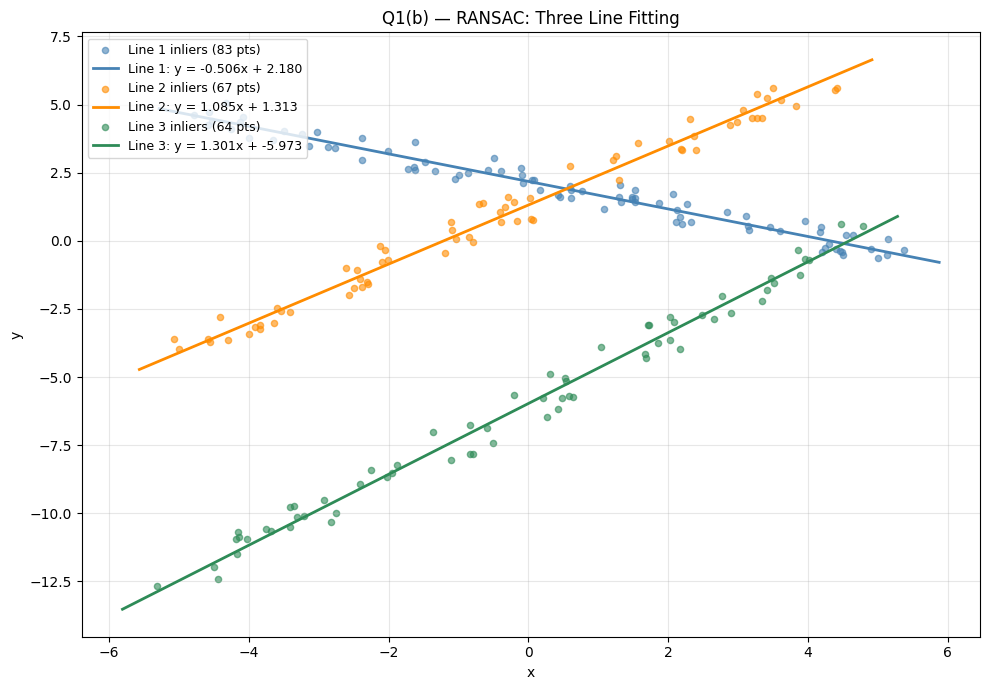

Plot saved to images/q1b_ransac_lines.png


In [8]:
colors = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(10, 7))

for i, ((a, b, d), (x_in, y_in)) in enumerate(zip(lines, inlier_sets)):
    
    # convert normal form to slope-intercept for plotting
    m = -a / b
    c = d / b
    
    ax.scatter(x_in, y_in, color=colors[i], s=20, alpha=0.6,
               label=f'Line {i+1} inliers ({len(x_in)} pts)')
    
    x_line = np.linspace(x_in.min() - 0.5, x_in.max() + 0.5, 200)
    y_line = m * x_line + c
    ax.plot(x_line, y_line, color=colors[i], linewidth=2,
            label=f'Line {i+1}: y = {m:.3f}x + {c:.3f}')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Q1(b) — RANSAC: Three Line Fitting')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../images/q1b_ransac_lines.png', dpi=150)
plt.show()
print("Plot saved to images/q1b_ransac_lines.png")

## Results Summary

| Line | Equation ax + by = d | Slope m | Intercept c | Inliers |
|------|----------------------|---------|-------------|---------|
| Line 1 | 0.4512x + 0.8924y = 1.9458 | -0.5056 | 2.1804 | 83 |
| Line 2 | 0.7353x + -0.6778y = -0.8900 | 1.0849 | 1.3131 | 67 |
| Line 3 | -0.7928x + 0.6095y = -3.6402 | 1.3009 | -5.9729 | 64 |

## Observation
RANSAC finds each line by running 1000 iterations of random 2-point sampling.
By removing inliers after each run, it separates the three clusters cleanly
even though all points were mixed together initially.

86 points (out of 300) were not assigned to any line — these are genuine 
outliers or points that fell between clusters.

The threshold=0.5 controls inlier strictness. The refit step at the end
of each RANSAC run gives a more accurate line than the best random sample alone.